2026-01-17 23:20:26,586 - __main__ - INFO - -------------------- Starting Episode 0 -------------------
2026-01-17 23:20:26,586 - __main__ - INFO - -------------------- Starting Episode 0 -------------------
2026-01-17 23:20:26,586 - __main__ - INFO - -------------------- Starting Episode 0 -------------------
2026-01-17 23:20:26,586 - __main__ - INFO - -------------------- Starting Episode 0 -------------------
2026-01-17 23:20:26,588 - PortfolioEnv - INFO - Cash: 10000.00 | Portfolio: 10000.00
2026-01-17 23:20:26,589 - PortfolioEnv - INFO - Action: [0.04993017 0.13572426 0.13572426 0.13572426 0.13572426 0.13572426
 0.13572426 0.13572426]
2026-01-17 23:20:26,589 - PortfolioEnv - INFO - Reward: -95.10
2026-01-17 23:20:26,590 - PortfolioEnv - INFO - Cash: 499.30 | Portfolio: 10000.00
2026-01-17 23:20:26,590 - PortfolioEnv - INFO - Action: [0.04993017 0.13572426 0.13572426 0.13572426 0.13572426 0.13572426
 0.13572426 0.13572426]
2026-01-17 23:20:26,590 - PortfolioEnv - INFO - Reward: 0.9

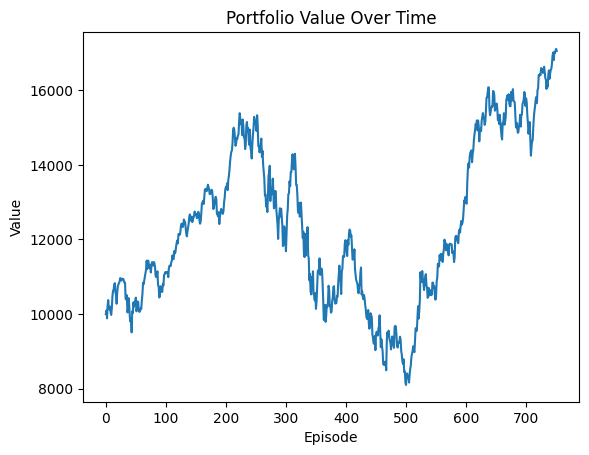

[[0.04993017 0.13572426 0.13572426 ... 0.13572426 0.13572426 0.13572426]
 [0.04993017 0.13572426 0.13572426 ... 0.13572426 0.13572426 0.13572426]
 [0.04993017 0.13572426 0.13572426 ... 0.13572426 0.13572426 0.13572426]
 ...
 [0.04993017 0.13572426 0.13572426 ... 0.13572426 0.13572426 0.13572426]
 [0.04993017 0.13572426 0.13572426 ... 0.13572426 0.13572426 0.13572426]
 [0.04993017 0.13572426 0.13572426 ... 0.13572426 0.13572426 0.13572426]]


/var/folders/lj/26vhzxbj5xsbxg8w05903y740000gn/T/ipykernel_30398/1661111294.py:151: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Assets", bbox_to_anchor=(1.05, 1), loc="upper left")


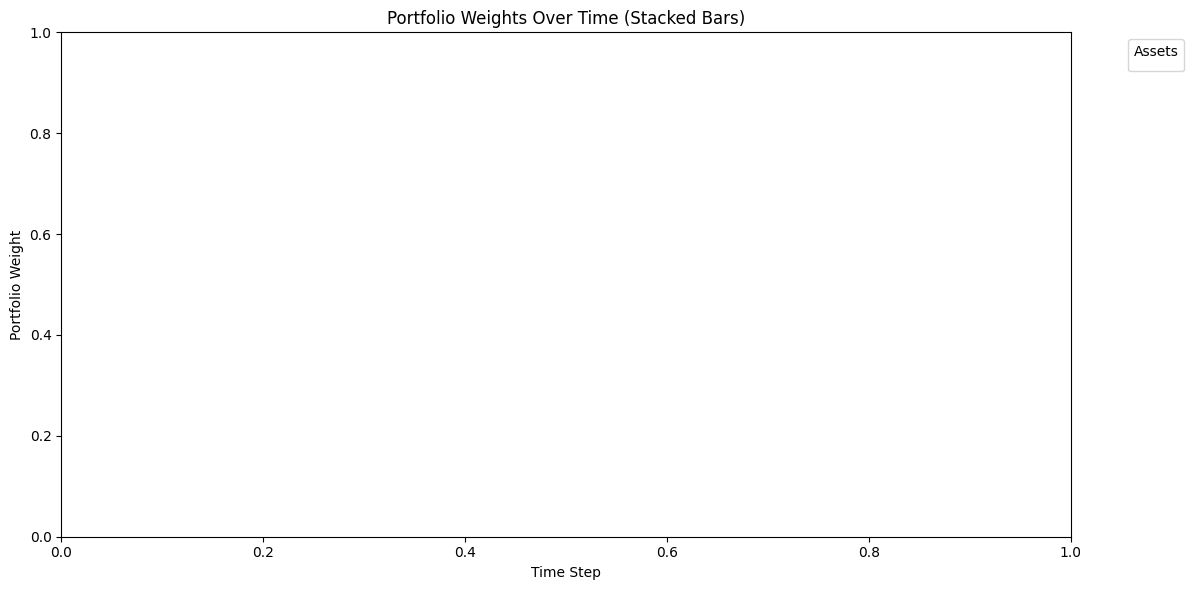

In [4]:
from models.td3 import TD3
from environment.portfolio import PortfolioEnv
from utils.logger import LoggerFactory
from data.data_processor import DataProcessor
import matplotlib.pyplot as plt
import numpy as np

logger = LoggerFactory.create_logger(__name__)

NUMBER_OF_EPISODES = 1
LEARNING_START_EPISODE = None
MODEL_PATH = "td3_model.pth"

tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "AMZN",  # Amazon
    "GOOGL", # Alphabet (Google)
    "META",  # Meta Platforms
    "TSLA",  # Tesla
    "NVDA",  # Nvidia
    # "JPM",   # JPMorgan Chase
    # "JNJ",   # Johnson & Johnson
    # "XOM"    # Exxon Mobil
]

# tickers = [
#     # Technology
#     "AAPL", "MSFT", "GOOGL", "META", "NVDA", "AMD", "INTC", "IBM",
#
#     # Consumer / Retail
#     "AMZN", "HD", "MCD", "NKE", "SBUX", "COST",
#
#     # Financials
#     "JPM", "BAC", "WFC", "GS", "MS",
#
#     # Healthcare
#     "JNJ", "PFE", "MRK", "ABBV", "UNH",
#
#     # Energy
#     "XOM", "CVX", "COP",
#
#     # Industrials
#     "CAT", "BA", "GE",
#
#     # Communications
#     "VZ", "T"
# ]


if __name__ == "__main__":

    dp = DataProcessor(data_dir="../indicators")
    df = dp.load_panel(
        tickers=tickers,
        start="2021-01-01",
        end="2024-01-01",
        # filter_cols=None  # netreba písať, default je None → načíta všetko z CSV
    )
    filter_out = [
        'obv', 'volume_base', 'open', 'high', 'low', 'unix'
    ]
    df_features = df.drop(columns=filter_out, level=1)
    df_prices = df.loc[:, (slice(None), ['close'])]
    data_3d_features, _, tickers, features = dp.to_3d(df_features)
    data_3d_prices, _, _, _ = dp.to_3d(df_prices)

    env = PortfolioEnv(features=data_3d_features, prices=data_3d_prices, num_assets=len(tickers), tickers=tickers)

    action_dim = env.action_space.shape[0]
    state_dim = int(env.observation_space.shape[0])
    td3_agent = TD3(state_dim=state_dim, action_dim=action_dim, noise_anneal_episodes = NUMBER_OF_EPISODES, learning_starts=LEARNING_START_EPISODE)
    td3_agent.load_model(MODEL_PATH)
    all_rewards = []
    all_portfolio_values = []
    all_critic_values = {
        "c1": [],
        "c2": []
    }
    all_weights = []

    # log_values_with_color(logger, {"Actor" : count_params(td3_agent.actor), "Critic1":
    #     count_params(td3_agent.critic1), "Critic2": count_params(td3_agent.critic2)}, use_color=False, level="info",)
    c = 0
    for episode in range(NUMBER_OF_EPISODES):
        logger.info(f"-------------------- Starting Episode {episode} -------------------")
        episode_reward = 0.0
        state = env.reset(options={"episode_number": episode})
        done = False

        prev_state = None
        prev_action = None

        while True:
            c = c + 1
            if done:
                break

            td3_agent.set_episode(episode)
            action, noisy_logits = td3_agent.select_action(state, 1, None, None, False)

            new_state, reward_val, done, trunc, info = env.step(action)
            all_portfolio_values.append(env.portfolio_value.curr)

            if prev_state is not None:
                env.replay_buffer.add(prev_state, prev_action, reward_val, done, state)

            prev_state = state
            prev_action = action
            state = new_state

            episode_reward += float(reward_val)
            # if c % 3 == 0:
            all_weights.append(env.portfolio_weights.curr)

    plt.plot(all_portfolio_values)
    plt.xlabel("Episode")
    plt.ylabel("Value")
    plt.title("Portfolio Value Over Time")
    plt.show()

    W = np.array(all_weights)   # (T, N)

    print(W)

    T, N = W.shape
    x = np.arange(T)

    # normalizácia aktív
    W = W / (W.sum(axis=1, keepdims=True) + 1e-12)

    # vypočítaj cash
    cash = 1.0 - W.sum(axis=1, keepdims=True)   # (T, 1)

    # spoj cash + aktíva (cash ako prvý)
    W = np.hstack([cash, W])

    labels = ["Cash"] + tickers

    plt.figure(figsize=(12, 6))
    bottom = np.zeros(T)
    #
    # for i in range(W.shape[1]):
    #     plt.bar(x, W[:, i], bottom=bottom, label=labels[i])
    #     bottom += W[:, i]

    plt.title("Portfolio Weights Over Time (Stacked Bars)")
    plt.xlabel("Time Step")
    plt.ylabel("Portfolio Weight")
    plt.ylim(0, 1)
    plt.legend(title="Assets", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
